In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import warnings

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from inflation_models import HiggsModel
import inf_dyn_background as bg
import inf_dyn_MS_full as ms_new
import inf_dyn_MS_old as ms_old

def calc_ns_for_k(k, solver, bg_sol, T_span, idx_end, model):
    delta = 1e-4
    ks = [k*(1-delta), k*(1+delta)]
    Ps = []
    
    start_log_az = bg_sol[3][:idx_end] + np.log(bg_sol[2][:idx_end])
    
    for kv in ks:
        target = np.log(kv) - np.log(100)
        s_idx = np.argmin(np.abs(start_log_az - target))
        if s_idx < 0: s_idx = 0
        
        xi = bg_sol[0][s_idx]
        yi = bg_sol[1][s_idx]
        zi = bg_sol[2][s_idx]
        ni = bg_sol[3][s_idx]
        
        T_ms = np.linspace(T_span[s_idx], T_span[idx_end], 5000)
        sol = solver(xi, yi, zi, ni, T_ms, kv, model)
        der = ms_new.get_ms_derived_quantities(sol, model, kv, ni)
        val = der['P_S'][-1]
        
        if np.isnan(val) or val <= 0: return np.nan
        Ps.append(val)
        
    return 1 + (np.log(Ps[1]) - np.log(Ps[0])) / (np.log(ks[1]) - np.log(ks[0]))

def process_phi0(phi0, y_init, model_class, N_star=60):
    model = model_class(xi=15000.0, lam=0.13)
    model.phi0 = phi0
    model.yi = y_init
    
    T_span = np.linspace(0, 5000, 50000)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        bg_sol = bg.run_background_simulation(model, T_span)
            
    derived = bg.get_derived_quantities(bg_sol, model)
    epsH = derived['epsH']
    N_efolds = derived['N']
    
    idx_end = np.argmax(epsH > 1.0)
    if idx_end == 0 and epsH[-1] < 1.0:
        idx_end = len(epsH) - 1
    elif idx_end == 0:
        return None
        
    N_total = N_efolds[idx_end]
    if N_total < N_star:
        return None
        
    N_pivot = N_total - N_star
    pivot_idx = np.argmin(np.abs(N_efolds[:idx_end] - N_pivot))
    
    z_pivot = bg_sol[2][pivot_idx]
    a_pivot = np.exp(bg_sol[3][pivot_idx])
    k_val = a_pivot * z_pivot
    
    ns_SR = derived['ns'][pivot_idx]
    
    ns_new = calc_ns_for_k(k_val, ms_new.run_ms_simulation, bg_sol, T_span, idx_end, model)
    ns_old = calc_ns_for_k(k_val, ms_old.run_ms_simulation, bg_sol, T_span, idx_end, model)
    
    if np.isnan(ns_new) or np.isnan(ns_old):
        return None
        
    return ns_SR, ns_new, ns_old

In [7]:
print("Sweeping phi0...")
y_init = -0.100
phi0_vals = np.linspace(5.92, 6.00, 30)

ns_SR_list = []
ns_new_list = []
ns_old_list = []
valid_phi0 = []

for i, phi in enumerate(phi0_vals):
    res = process_phi0(phi, y_init, HiggsModel)
    if res is not None:
        ns_SR, ns_new, ns_old = res
        ns_SR_list.append(ns_SR)
        ns_new_list.append(ns_new)
        ns_old_list.append(ns_old)
        valid_phi0.append(phi)
        print(f"[{i+1}/{len(phi0_vals)}] phi0 = {phi:.4f}: Exact={ns_new:.4f}, Old={ns_old:.4f}, SR={ns_SR:.4f}")

valid_phi0 = np.array(valid_phi0)
ns_SR_arr = np.array(ns_SR_list)
ns_new_arr = np.array(ns_new_list)
ns_old_arr = np.array(ns_old_list)
print("\nExtraction complete.")

Sweeping phi0...
OLD INITIAL_STATE:
xi 5.510737794853804
yi -0.002506352138278344
zi 0.13723909313186547
ni -1.0938440288998492
vi 0.19055220573355983
ui 0
v_Ti 0
u_Ti -2.623952832638035
OLD INITIAL_STATE:
xi 5.510737794853804
yi -0.002506352138278344
zi 0.13723909313186547
ni -1.0938440288998492
vi 0.19053315146565225
ui 0
v_Ti 0
u_Ti -2.6242152410423754
[1/30] phi0 = 5.9200: Exact=0.9679, Old=0.9750, SR=0.9674
OLD INITIAL_STATE:
xi 5.510656555009672
yi -0.0025065175667576
zi 0.1372389913205911
ni -0.9151684707262524
vi 0.19055263711258275
ui 0
v_Ti 0
u_Ti -2.6239468924515013
OLD INITIAL_STATE:
xi 5.510656555009672
yi -0.0025065175667576
zi 0.1372389913205911
ni -0.9151684707262524
vi 0.19053358280153937
ui 0
v_Ti 0
u_Ti -2.6242093002617928
[2/30] phi0 = 5.9228: Exact=0.9679, Old=0.9750, SR=0.9674
OLD INITIAL_STATE:
xi 5.510833090309467
yi -0.0025061581022117183
zi 0.13723921254903823
ni -0.750212716401405
vi 0.19055169976328162
ui 0
v_Ti 0
u_Ti -2.623959799997269
OLD INITIAL_STATE:
x

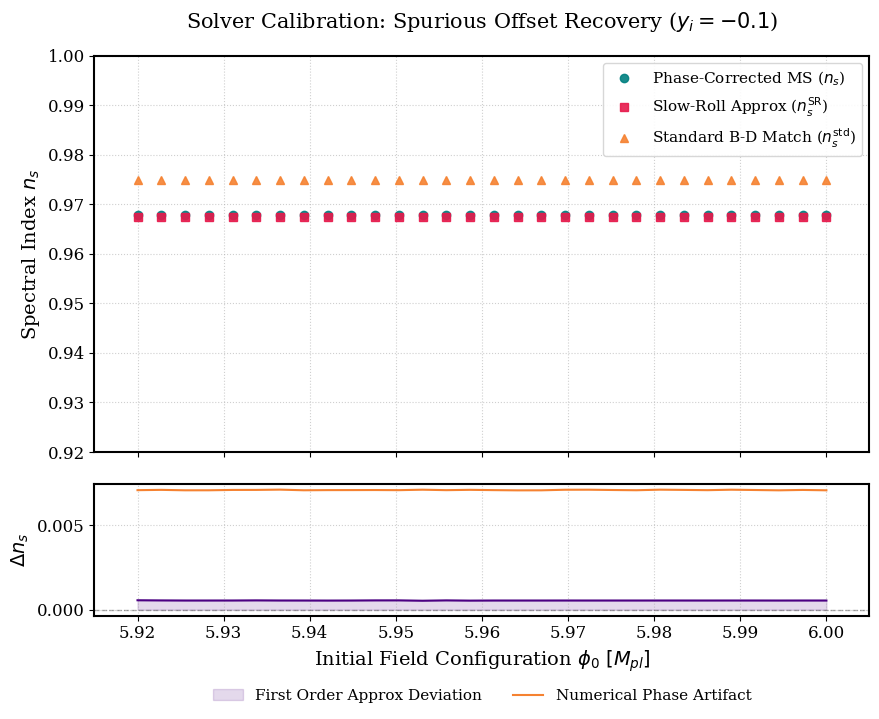

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 13 
plt.rcParams['axes.linewidth'] = 1.5

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               sharex=True)


ax1.plot(valid_phi0, ns_new_arr, label=r'Phase-Corrected MS ($n_s$)', 
         color='#008080', marker='o', markersize=6, ls='none', alpha=0.9)
# Analytical SR
ax1.plot(valid_phi0, ns_SR_arr, label=r'Slow-Roll Approx ($n_s^{\mathrm{SR}}$)', 
         color='#e6194b', marker='s', markersize=6, ls='none', alpha=0.9)
ax1.plot(valid_phi0, ns_old_arr, label=r'Standard B-D Match ($n_s^{\mathrm{std}}$)', 
         color='#f58231', marker='^', markersize=6, ls='none', alpha=0.9)

ax1.set_xlim([min(valid_phi0)-0.005, max(valid_phi0)+0.005])
ax1.set_ylim([0.92, 1.00]) 
ax1.set_ylabel(r'Spectral Index $n_s$', fontsize=14)
ax1.set_title(f'Solver Calibration: Spurious Offset Recovery ($y_i = {y_init}$)', fontsize=15, pad=20)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', fontsize=11, frameon=True, framealpha=0.9, edgecolor='lightgray')

resid_phys = ns_new_arr - ns_SR_arr   
resid_art  = ns_old_arr - ns_new_arr  

ax2.plot(valid_phi0, resid_phys, color='#4b0082', lw=1.5)
ax2.fill_between(valid_phi0, resid_phys, 0, color='#4b0082', alpha=0.15, label='First Order Approx Deviation')

ax2.axhline(0, color='black', lw=1, ls='--', alpha=0.3)
ax2.plot(valid_phi0, resid_art, color='#f58231', lw=1.5, ls='-', label='Numerical Phase Artifact')

ax2.set_xlabel(r'Initial Field Configuration $\phi_0$ $[M_{pl}]$', fontsize=14)
ax2.set_ylabel(r'$\Delta n_s$', fontsize=14)
ax2.grid(True, linestyle=':', alpha=0.6)

ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.45), ncol=2, fontsize=11, frameon=False)

for ax in [ax1, ax2]:
    ax.tick_params(axis='both', which='major', labelsize=12)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

plt.subplots_adjust(hspace=0.12, bottom=0.18) 

os.makedirs('../images', exist_ok=True)
plt.savefig('../images/ns_offset_calibration.png', dpi=300, bbox_inches='tight')
plt.show()
